In [ ]:
# Install library 
# !pip install -U langchain langchain-community langchain-core

In [ ]:
!pip install langchain-ollama

Langchain BaseStore

In [ ]:
from langchain_core.stores import BaseStore
from typing import List, Tuple, Optional, Iterator

class InMemoryStore(BaseStore[str, str]):
    def __init__(self):
        self.store = {}

    def mget(self, keys: List[str]) -> List[Optional[str]]:
        return [self.store.get(k) for k in keys]

    def mset(self, key_value_pairs: List[Tuple[str, str]]) -> None:
        for key, value in key_value_pairs:
            self.store[key] = value

    def mdelete(self, keys: List[str]) -> None:
        for key in keys:
            self.store.pop(key, None)

    def yield_keys(self, prefix: Optional[str] = None) -> Iterator[str]:
        for key in self.store:
            if prefix is None or key.startswith(prefix):
                yield key

In [ ]:
store = InMemoryStore()

store.mset([("a", "1"), ("b", "2")])

print(store.mget(["a", "b", "c"]))
# ['1', '2', None]

store.mdelete(["b"])

print(list(store.yield_keys()))
# ['a']

InMemoryCache

In [1]:
import time
from langchain_community.llms import Ollama
from langchain_core.caches import InMemoryCache

# 1. Create the cache object
my_private_cache = InMemoryCache()

# 2. Initialize Ollama and EXPLICITLY pass the cache to it
llm = Ollama(model="llama3.2:1b", temperature=0, cache=my_private_cache)

def test_cache(prompt):
    start = time.time()
    response = llm.invoke(prompt)
    print(f"Response: {response}")
    print(f"Time: {time.time() - start:.4f}s")

print("--- Run 1 ---")
test_cache("What is the square root of 144?")

print("\n--- Run 2 (Should be 0.000x) ---")
test_cache("What is the square root of 144?")

C:\Users\USER\AppData\Local\Temp\ipykernel_9040\2853796538.py:9: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="llama3.2:1b", temperature=0, cache=my_private_cache)


--- Run 1 ---
Response: The square root of 144 is 12.
Time: 3.4319s

--- Run 2 (Should be 0.000x) ---
Response: The square root of 144 is 12.
Time: 0.0000s


In [6]:
from langchain_community.llms import Ollama
from langchain_core.caches import InMemoryCache

# 1. Initialize the Cache
my_cache = InMemoryCache()

# 2. Connect the Cache to the Model
llm = Ollama(model="llama3.2:1b", cache=my_cache)

# 3. Demonstrate the hit
response = llm.invoke("What is the capital of India?")
print(response)

The capital of India is New Delhi.


In [7]:
response

'The capital of India is New Delhi.'

In [4]:
from langchain_ollama import OllamaLLM
from langchain_core.caches import InMemoryCache
from langchain_core.outputs import Generation

# Setup
llm = OllamaLLM(model="llama3.2:1b")
cache = InMemoryCache()
llm_string = str(llm._identifying_params)

def ask_assistant(question):
    # 1. Manual Lookup: Check if we already know this
    cached_val = cache.lookup(question, llm_string)
    
    if cached_val:
        print(f"🚀 [CACHE HIT] {question}")
        return cached_val[0].text
    else:
        print(f"🧠 [LLM THINKING] {question}")
        # 2. If not in cache, call the LLM
        response = llm.invoke(question)
        # 3. Manual Update: Save it for next time
        cache.update(question, llm_string, [Generation(text=response)])
        return response

# Test Run
q = "How many colors are in a rainbow?"

print(ask_assistant(q)) # First time: Calls the LLM


🧠 [LLM THINKING] How many colors are in a rainbow?
A rainbow is actually made up of seven distinct colors, which always appear in the same order. They are:

1. Red
2. Orange
3. Yellow
4. Green
5. Blue
6. Indigo
7. Violet

These colors are also sometimes remembered using the acronym ROYGBIV, with each letter standing for the name of a color.

It's worth noting that some people may see different colors in a rainbow depending on their individual vision or the lighting conditions. But the seven colors listed above are the traditional and widely accepted colors of a rainbow.


In [5]:
print(ask_assistant(q)) # Second time: Instant from Cache

🚀 [CACHE HIT] How many colors are in a rainbow?
A rainbow is actually made up of seven distinct colors, which always appear in the same order. They are:

1. Red
2. Orange
3. Yellow
4. Green
5. Blue
6. Indigo
7. Violet

These colors are also sometimes remembered using the acronym ROYGBIV, with each letter standing for the name of a color.

It's worth noting that some people may see different colors in a rainbow depending on their individual vision or the lighting conditions. But the seven colors listed above are the traditional and widely accepted colors of a rainbow.


BaseCache

In [2]:
import time
from langchain_ollama import ChatOllama
from langchain_core.globals import set_llm_cache
from langchain_core.caches import InMemoryCache

# 1. Initialize the Cache
# This tells LangChain to use an In-Memory storage for all LLM calls
set_llm_cache(InMemoryCache())

# 2. Initialize the Ollama Model
llm = ChatOllama(model="llama3.2:1b", temperature=0)

def ask_question(question):
    start_time = time.time()
    response = llm.invoke(question)
    end_time = time.time()
    
    print(f"Question: {question}")
    print(f"Response: {response.content[:50]}...")
    print(f"Time Taken: {end_time - start_time:.3f} seconds\n")

# --- First Call (Cache Miss) ---
print("--- Request 1 (First time, should be slow) ---")
ask_question("What is the capital of France?")



--- Request 1 (First time, should be slow) ---
Question: What is the capital of France?
Response: The capital of France is Paris....
Time Taken: 1.073 seconds



In [3]:
# --- Second Call (Cache Hit) ---
print("--- Request 2 (Identical prompt, should be instant) ---")
ask_question("What is the capital of France?")

--- Request 2 (Identical prompt, should be instant) ---
Question: What is the capital of France?
Response: The capital of France is Paris....
Time Taken: 0.000 seconds



BaseCache: The Blueprint
BaseCache is part of langchain-core. It exists to ensure that no matter what database you use (Redis, SQLite, MongoDB), the rest of LangChain knows exactly which methods to call. It forces every cache to have:

A lookup method to find data.

An update method to save data.

A clear method to delete data.

If you wanted to create a custom cache for a niche database that LangChain doesn't support yet, you would inherit from BaseCache.

InMemoryCache: The Default Tool
InMemoryCache is the simplest implementation of BaseCache. It stores your LLM prompts and responses in a standard Python dictionary {}.

Pros:
Speed: Accessing RAM is the fastest possible way to retrieve data.

Zero Config: You don't need to install a database like Redis or manage file paths like SQLite.

Cons:
Volatile: If your Python script crashes or you restart your IDE, the cache is wiped clean.

Memory Usage: If you have thousands of long conversations, it will eat up your computer's RAM.

Which one should you use?
Use InMemoryCache when you are prototyping or running a single-session script where you don't care about saving the cache for tomorrow.

Use BaseCache only if you are a developer looking to build a brand-new caching plugin for the LangChain ecosystem.

Use SQLiteCache or RedisCache if you need the cache to stay alive after you turn off your computer.

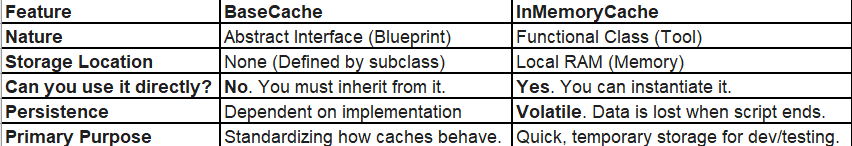